In [1]:
import pandas as pd
import re
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [5]:
import json

# List to store successfully parsed JSON objects
parsed_data = []

with open('news.json', 'r') as f:
    for line_num, line in enumerate(f):
        try:
            parsed_data.append(json.loads(line))
        except json.JSONDecodeError as e:
            print(f"Skipping malformed JSON line {line_num + 1}: {line.strip()} - Error: {e}")

data = pd.DataFrame(parsed_data)

# reduce size for faster training
data = data.sample(20000, random_state=42).reset_index(drop=True)

data.head()

Skipping malformed JSON line 141349: {"category": "ENVIRONMENT", "headline": "Alligator Crittercams Offer Unprecedented Look Into Reptiles' Lives (VIDEO)", "authors": "", "link": "https://www.huffingtonpost.com/entry/alligator-crittercams-video_us_5bb14f1ce4b09bbe9a5e3306", "short_description": "As shown in the video, installing the cameras was no easy feat. The researchers had to catch the alligators, hold them down", "date": "2014-01 - Error: Unterminated string starting at: line 1 column 395 (char 394)


,link,headline,category,short_description,authors,date
0,https://www.huffingtonpost.com/entry/my-super-...,My Super Bowl Victory in Weight Loss,BUSINESS,They say it is hard to repeat as Super Bowl ch...,"Don McNay, ContributorBest selling lottery and...",2015-02-01
1,https://www.huffingtonpost.com/entry/shark-att...,Shark Kills Diver While Daughter Watches In Ho...,GREEN,The two were diving for scallops when the atta...,Carla Herreria,2015-07-25
2,https://www.huffingtonpost.comhttp://www.peopl...,Taylor Swift Rocks Her BFF's Birthday Party,ENTERTAINMENT,,,2015-04-05
3,https://www.huffingtonpost.com/entry/shocked-s...,"Shocked, Shocked",COMEDY,,"Stanton Peele, ContributorAddiction expert",2014-07-01
4,https://www.huffingtonpost.com/entry/tech-bear...,This 'Tech Bear' Couple Bought 'JebBushForPres...,QUEER VOICES,,JamesMichael Nichols,2015-01-28


In [6]:
# combine text
data['text'] = data['headline'] + " " + data['short_description']

# clean text
def clean_text(text):
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

data['text'] = data['text'].apply(clean_text)

# remove missing
data = data.dropna(subset=['text', 'category']).reset_index(drop=True)

In [8]:
from transformers import AutoModelForSequenceClassification
import torch
from sklearn.preprocessing import LabelEncoder # Added this import

# Ensure 'label' column is created before use
if 'label' not in data.columns:
    le = LabelEncoder()
    data['label'] = le.fit_transform(data['category'])

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(data['label'].unique())
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


cuda


In [9]:
le = LabelEncoder()
data['label'] = le.fit_transform(data['category'])

In [10]:
x_train, x_temp, y_train, y_temp = train_test_split(
    data['text'], data['label'], test_size=0.3, random_state=42
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.5, random_state=42
)

# reset index (IMPORTANT)
x_train = x_train.reset_index(drop=True)
x_val = x_val.reset_index(drop=True)
x_test = x_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [11]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(list(x_train), padding=True, truncation=True, max_length=64)
val_encodings = tokenizer(list(x_val), padding=True, truncation=True, max_length=64)
test_encodings = tokenizer(list(x_test), padding=True, truncation=True, max_length=64)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [12]:
class NewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [13]:
train_dataset = NewsDataset(train_encodings, y_train)
val_dataset = NewsDataset(val_encodings, y_val)
test_dataset = NewsDataset(test_encodings, y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

In [14]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(data['label'].unique())
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
import torch
print(torch.cuda.is_available())

True


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(device)

cuda


In [17]:
optimizer = AdamW(model.parameters(), lr=2e-5)

In [18]:
model.train()

for epoch in range(1):
    total_loss = 0

    for batch in tqdm(train_loader):
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {total_loss}")

100%|██████████| 875/875 [03:10<00:00,  4.60it/s]

Epoch 1, Loss: 1919.8879722952843


In [19]:
model.eval()

preds = []
true_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)

        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)

        preds.extend(predictions.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

100%|██████████| 188/188 [00:12<00:00, 14.77it/s]


In [20]:
print("Accuracy:", accuracy_score(true_labels, preds))
print("Precision:", precision_score(true_labels, preds, average='weighted'))
print("Recall:", recall_score(true_labels, preds, average='weighted'))
print("F1 Score:", f1_score(true_labels, preds, average='weighted'))

Accuracy: 0.551
Precision: 0.49764014657435307
Recall: 0.551
F1 Score: 0.4839891675974105


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [21]:
print("Accuracy:", accuracy_score(true_labels, preds))
print("Precision:", precision_score(true_labels, preds, average='weighted'))
print("Recall:", recall_score(true_labels, preds, average='weighted'))
print("F1 Score:", f1_score(true_labels, preds, average='weighted'))

Accuracy: 0.551
Precision: 0.49764014657435307
Recall: 0.551
F1 Score: 0.4839891675974105


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [22]:
# experiment 1 :Freeze BERT layers and train classifier
# ── Load fresh model ──────────────────────────────────────────────────────────
model_exp1 = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(data['label'].unique())
)
model_exp1.to(device)

# Freeze every BERT layer — only the classifier head will be trained
for param in model_exp1.bert.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in model_exp1.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable:,}")   # should be ~7,700 (just the linear head)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters: 32,298


In [24]:
def train_epoch(model, data_loader, optimizer, device):
    model.train()
    total_loss = 0
    for batch in tqdm(data_loader):
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
    return total_loss

In [27]:
def evaluate_model(model, data_loader, device):
    model.eval()
    all_preds = []
    all_true_labels = []

    with torch.no_grad():
        for batch in tqdm(data_loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=1)

            all_preds.extend(predictions.cpu().numpy())
            all_true_labels.extend(labels.cpu().numpy())

    return all_true_labels, all_preds

In [29]:
def plot_cm(true_labels, preds, title="Confusion Matrix"):
    cm = confusion_matrix(true_labels, preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

In [28]:
def print_metrics(true_labels, preds, experiment_name="Experiment"):
    accuracy = accuracy_score(true_labels, preds)
    precision = precision_score(true_labels, preds, average='weighted', zero_division=0)
    recall = recall_score(true_labels, preds, average='weighted', zero_division=0)
    f1 = f1_score(true_labels, preds, average='weighted', zero_division=0)

    print(f"\n--- {experiment_name} Metrics ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

In [25]:
optimizer_exp1 = AdamW(
    filter(lambda p: p.requires_grad, model_exp1.parameters()), lr=1e-3
)

print("Training Experiment 1: Frozen BERT...")
for epoch in range(3):
    loss = train_epoch(model_exp1, train_loader, optimizer_exp1, device)
    print(f"  Epoch {epoch+1} | Loss: {loss:.4f}")

Training Experiment 1: Frozen BERT...


100%|██████████| 875/875 [01:03<00:00, 13.87it/s]


  Epoch 1 | Loss: 2536.6713


100%|██████████| 875/875 [01:01<00:00, 14.22it/s]


  Epoch 2 | Loss: 2269.5228


100%|██████████| 875/875 [01:01<00:00, 14.20it/s]

  Epoch 3 | Loss: 2143.8076


100%|██████████| 188/188 [00:13<00:00, 14.18it/s]



--- Experiment 1 — Frozen BERT Metrics ---
Accuracy: 0.3810
Precision: 0.3071
Recall: 0.3810
F1 Score: 0.2695


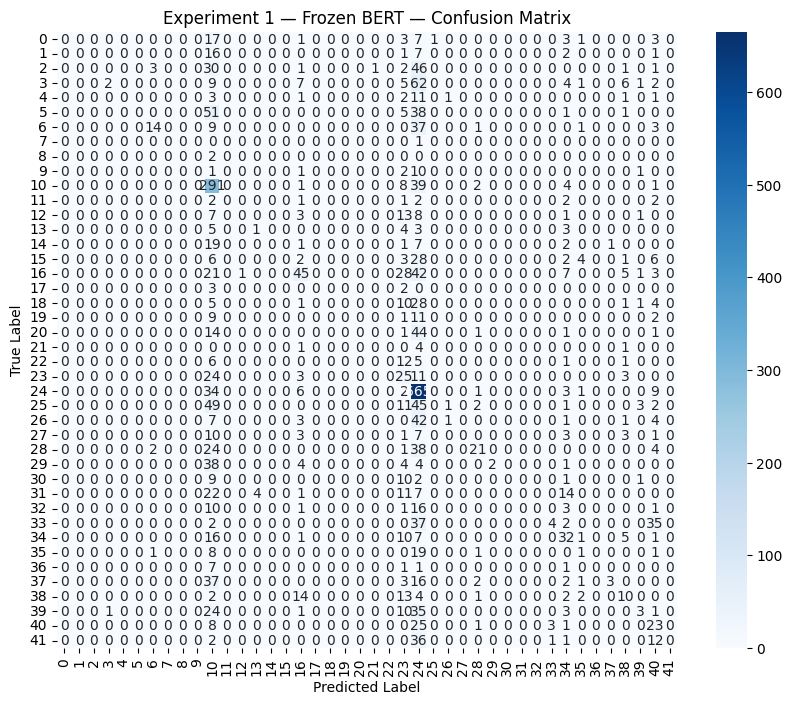

In [30]:
true_exp1, pred_exp1 = evaluate_model(model_exp1, test_loader, device)
metrics_exp1 = print_metrics(true_exp1, pred_exp1, "Experiment 1 — Frozen BERT")
plot_cm(true_exp1, pred_exp1, "Experiment 1 — Frozen BERT — Confusion Matrix")

In [31]:
# Experiment 2 — Fine-Tune Last 2 BERT Layers + Classifier
# ── Load fresh model ──────────────────────────────────────────────────────────
model_exp2 = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(data['label'].unique())
)
model_exp2.to(device)

# Step 1: Freeze everything first
for param in model_exp2.bert.parameters():
    param.requires_grad = False

# Step 2: Unfreeze ONLY the last 2 encoder layers (layers 10 and 11)
# BERT-base has 12 layers (index 0 to 11)
for layer in model_exp2.bert.encoder.layer[-2:]:
    for param in layer.parameters():
        param.requires_grad = True

# The classifier head is trainable by default (not inside .bert)
trainable = sum(p.numel() for p in model_exp2.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable:,}")   # ~14M out of 110M

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters: 14,208,042


In [32]:
optimizer_exp2 = AdamW(
    filter(lambda p: p.requires_grad, model_exp2.parameters()), lr=2e-5
)

print("Training Experiment 2: Last 2 Layers + Classifier...")
for epoch in range(3):
    loss = train_epoch(model_exp2, train_loader, optimizer_exp2, device)
    print(f"  Epoch {epoch+1} | Loss: {loss:.4f}")

Training Experiment 2: Last 2 Layers + Classifier...


100%|██████████| 875/875 [01:22<00:00, 10.64it/s]


  Epoch 1 | Loss: 2221.0908


100%|██████████| 875/875 [01:21<00:00, 10.79it/s]


  Epoch 2 | Loss: 1649.2516


100%|██████████| 875/875 [01:21<00:00, 10.74it/s]

  Epoch 3 | Loss: 1448.5212


100%|██████████| 188/188 [00:12<00:00, 14.64it/s]



--- Experiment 2 — Last 2 Layers Metrics ---
Accuracy: 0.5560
Precision: 0.5067
Recall: 0.5560
F1 Score: 0.4982


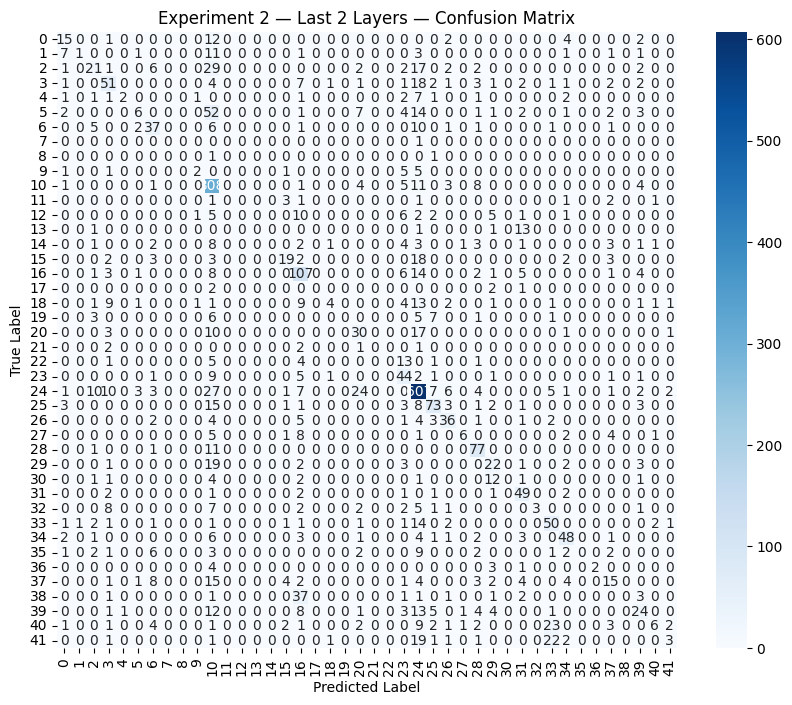

In [33]:
true_exp2, pred_exp2 = evaluate_model(model_exp2, test_loader, device)
metrics_exp2 = print_metrics(true_exp2, pred_exp2, "Experiment 2 — Last 2 Layers")
plot_cm(true_exp2, pred_exp2, "Experiment 2 — Last 2 Layers — Confusion Matrix")

In [34]:
# Comparison — All Experiments Side by Side
# ── Metrics from your original Step 13-14 (full fine-tuning) ─────────────────
# Re-run evaluate on your original model to get metrics in the same format
true_base, pred_base = evaluate_model(model, test_loader, device)
metrics_base = print_metrics(true_base, pred_base, "Baseline — Full Fine-Tuning")

100%|██████████| 188/188 [00:13<00:00, 13.72it/s]


--- Baseline — Full Fine-Tuning Metrics ---
Accuracy: 0.5510
Precision: 0.4976
Recall: 0.5510
F1 Score: 0.4840


In [37]:
# ── Build comparison table ────────────────────────────────────────────────────
comparison_df = pd.DataFrame({
    'Experiment'  : ['Full Fine-Tuning', 'Frozen BERT', 'Last 2 Layers'],
    'Accuracy'    : [metrics_base['accuracy'],   metrics_exp1['accuracy'],   metrics_exp2['accuracy']],
    'Precision'   : [metrics_base['precision'],  metrics_exp1['precision'],  metrics_exp2['precision']],
    'Recall'      : [metrics_base['recall'],     metrics_exp1['recall'],     metrics_exp2['recall']],
    'F1 Score'    : [metrics_base['f1'],   metrics_exp1['f1'],   metrics_exp2['f1']]
})

comparison_df = comparison_df.set_index('Experiment')
print(comparison_df.round(4))

                  Accuracy  Precision  Recall  F1 Score
Experiment                                             
Full Fine-Tuning     0.551     0.4976   0.551    0.4840
Frozen BERT          0.381     0.3071   0.381    0.2695
Last 2 Layers        0.556     0.5067   0.556    0.4982


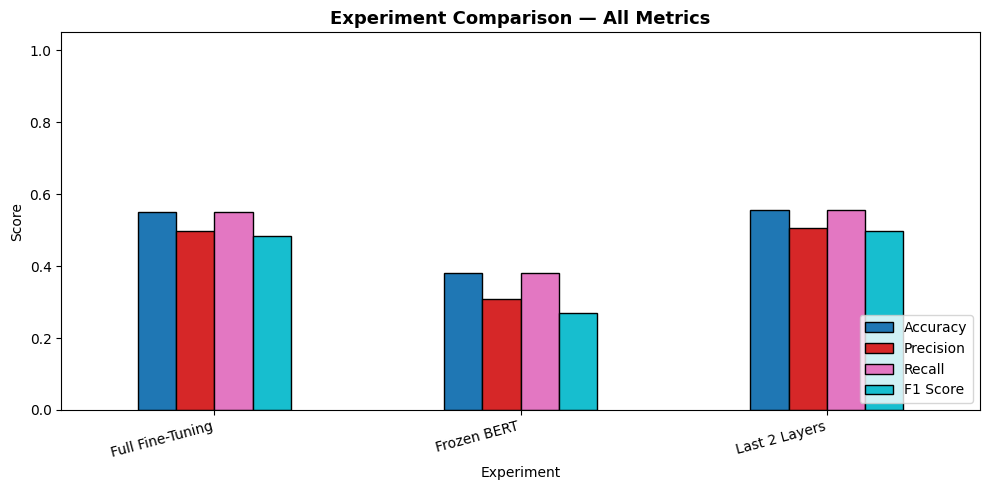

In [38]:
# ── Bar chart ─────────────────────────────────────────────────────────────────
ax = comparison_df.plot(kind='bar', figsize=(10, 5), colormap='tab10', edgecolor='black')
plt.title('Experiment Comparison — All Metrics', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=15, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()